# UK Electricity Demand — Probabilistic Forecast (Kaggle, multi-accelerator)

Self-contained end-to-end demo of the **GPU-Accelerated Probabilistic Grid Load Forecaster** project.

**Pipeline.** load → features → fit → evaluate → plot.

**Model.** A small MLP whose output head parameterises a **sinh-arcsinh** predictive distribution (Jones & Pewsey, 2009, *Biometrika* 96(4): 761–780) with location $\mu$, scale $\sigma$, skew $\varepsilon$, kurtosis $\delta$.

**Metrics.** Pinball loss at 7 quantiles, sample-based CRPS, 80% / 95% prediction-interval coverage.

**Accelerators.** Auto-detects: PyTorch on **CUDA** (P100, T4 x2 — single device) or `torch_xla` on **TPU v5e-8** (single core). Falls back to CPU if neither is available, with a synthetic-data path so the notebook runs anywhere.


## 1. Optional install

Kaggle GPU images come with `torch` preinstalled; TPU 1VM images come with `torch_xla` preinstalled. Leave commented unless the next cell fails.


In [1]:
# !pip install --quiet torch
# !pip install --quiet "torch_xla[tpu]" -f https://storage.googleapis.com/libtpu-releases/index.html


## 2. Accelerator detection


In [2]:
from __future__ import annotations

import platform
import sys

import torch

BACKEND = "cpu"
device = torch.device("cpu")
xm = None

try:
    import torch_xla.core.xla_model as _xm

    _dev = _xm.xla_device()
    BACKEND = "xla"
    xm = _xm
    device = _dev
except Exception:
    if torch.cuda.is_available():
        BACKEND = "cuda"
        device = torch.device("cuda:0")

print(f"Python   : {sys.version.split()[0]} on {platform.system()}")
print(f"Torch    : {torch.__version__}")
print(f"Backend  : {BACKEND}")
print(f"Device   : {device}")
if BACKEND == "cuda":
    print(f"CUDA count : {torch.cuda.device_count()}")
    print(f"CUDA name  : {torch.cuda.get_device_name(0)}")


Python   : 3.12.13 on Linux
Torch    : 2.10.0+cu128
Backend  : cuda
Device   : cuda:0
CUDA count : 2
CUDA name  : Tesla T4


## 3. Imports and seeds


In [3]:
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if BACKEND == "cuda":
    torch.cuda.manual_seed_all(SEED)


## 4. Data load

Set `DATASET_NAME` to the slug of the Kaggle dataset you attached (it appears as a subfolder under `/kaggle/input/`). The loader walks the directory, picks up any CSV / Parquet, and auto-detects a datetime column and a demand column.

If nothing is found (e.g. running locally), it falls back to a synthetic half-hourly series so the notebook is always runnable.


In [4]:
import warnings

KAGGLE_INPUT = Path("/kaggle/input")
DATASET_NAME = "electricity-consumption-uk-20092022"  # <-- slug of the dataset you attached

DATETIME_HINTS = ("settlement_date", "settlementdate", "datetime", "timestamp", "date", "ds")
PERIOD_HINTS = ("settlement_period", "settlementperiod", "period", "sp")
DEMAND_HINTS = ("nd", "tsd", "england_wales_demand", "demand", "load", "y")


def _pick_col(df: pd.DataFrame, hints: tuple[str, ...]) -> str | None:
    lower = {c.lower(): c for c in df.columns}
    for h in hints:
        if h in lower:
            return lower[h]
    for h in hints:
        for c_lower, c in lower.items():
            if h in c_lower:
                return c
    return None


def _read_any(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)


def _find_data_files() -> list[Path]:
    if not KAGGLE_INPUT.exists():
        return []
    primary = KAGGLE_INPUT / DATASET_NAME
    files: list[Path] = []
    if primary.exists():
        files += list(primary.rglob("*.csv")) + list(primary.rglob("*.parquet"))
    if not files:
        for sub in KAGGLE_INPUT.iterdir():
            if sub.is_dir():
                files += list(sub.rglob("*.csv")) + list(sub.rglob("*.parquet"))
    return files


def _parse_dates(s: pd.Series) -> pd.Series:
    """Parse a date column via its unique values (fast) and silence the
    inferred-format warning. dayfirst=True matches the UK NESO DD/MM/YYYY style;
    ISO dates are unaffected."""
    s = s.astype(str)
    uniq = pd.Index(s.unique())
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        parsed = pd.to_datetime(uniq, errors="coerce", dayfirst=True)
    lookup = pd.Series(parsed, index=uniq)
    return s.map(lookup)


def _to_demand_frame(df: pd.DataFrame) -> pd.DataFrame | None:
    """Map one raw file to a (datetime-indexed, 'demand') frame, or None if it
    has no recognisable date/demand columns."""
    dcol = _pick_col(df, DATETIME_HINTS)
    ycol = _pick_col(df, DEMAND_HINTS)
    if not (dcol and ycol):
        return None
    pcol = _pick_col(df, PERIOD_HINTS)
    base = _parse_dates(df[dcol])
    # NESO-family files split time across SETTLEMENT_DATE (a calendar date) and
    # SETTLEMENT_PERIOD (1..48). Reconstruct a half-hourly timestamp when the period
    # column is present; otherwise the datetime column already carries the time.
    if pcol is not None and pcol != dcol:
        period = pd.to_numeric(df[pcol], errors="coerce")
        ts = base + pd.to_timedelta((period - 1) * 30, unit="min")
    else:
        ts = base
    out = pd.DataFrame({"datetime": ts.values, "demand": df[ycol].values})
    out["demand"] = pd.to_numeric(out["demand"], errors="coerce")
    out = out.dropna(subset=["datetime", "demand"]).set_index("datetime")
    return out


def _synthetic_demand(years: int = 2) -> pd.DataFrame:
    n = years * 365 * 48
    idx = pd.date_range("2022-01-01", periods=n, freq="30min")
    t = np.arange(n)
    daily = 8.0 * np.sin(2 * np.pi * t / 48 - 1.5)
    weekly = 2.0 * np.sin(2 * np.pi * t / (48 * 7))
    annual = 5.0 * np.sin(2 * np.pi * t / (48 * 365) - 1.0)
    trend = 30.0
    noise = np.zeros(n)
    rng = np.random.default_rng(SEED)
    for i in range(1, n):
        noise[i] = 0.85 * noise[i - 1] + rng.normal(0.0, 0.6)
    return pd.DataFrame({"demand": trend + daily + weekly + annual + noise}, index=idx)


def load_demand() -> tuple[pd.DataFrame, str]:
    # The dataset ships one CSV per year; concatenate every recognisable file so the
    # full history (not just the first year) is used.
    frames: list[pd.DataFrame] = []
    used: list[str] = []
    for f in _find_data_files():
        try:
            df = _read_any(f)
        except Exception:
            continue
        out = _to_demand_frame(df)
        if out is not None and len(out):
            frames.append(out)
            used.append(str(f.relative_to(KAGGLE_INPUT)))
    if frames:
        full = pd.concat(frames).sort_index()
        full = full[~full.index.duplicated(keep="first")]
        if len(full) >= 1000:
            tag = used[0] if len(used) == 1 else f"{Path(used[0]).parent} ({len(used)} files)"
            return full, f"kaggle:{tag}"
    return _synthetic_demand(), "synthetic"


demand_df, source_tag = load_demand()
print(f"Source : {source_tag}")
print(f"Rows   : {len(demand_df):,}")
print(f"Range  : {demand_df.index.min()} -> {demand_df.index.max()}")
demand_df.head()


Source : kaggle:datasets/albertovidalrod/electricity-consumption-uk-20092022 (18 files)
Rows   : 249,142
Range  : 2009-01-01 00:00:00 -> 2024-12-12 23:00:00


,demand
datetime,
2009-01-01 00:00:00,37910
2009-01-01 00:30:00,38047
2009-01-01 01:00:00,38047
2009-01-01 01:30:00,36426
2009-01-01 02:00:00,35687


## 5. Quick EDA


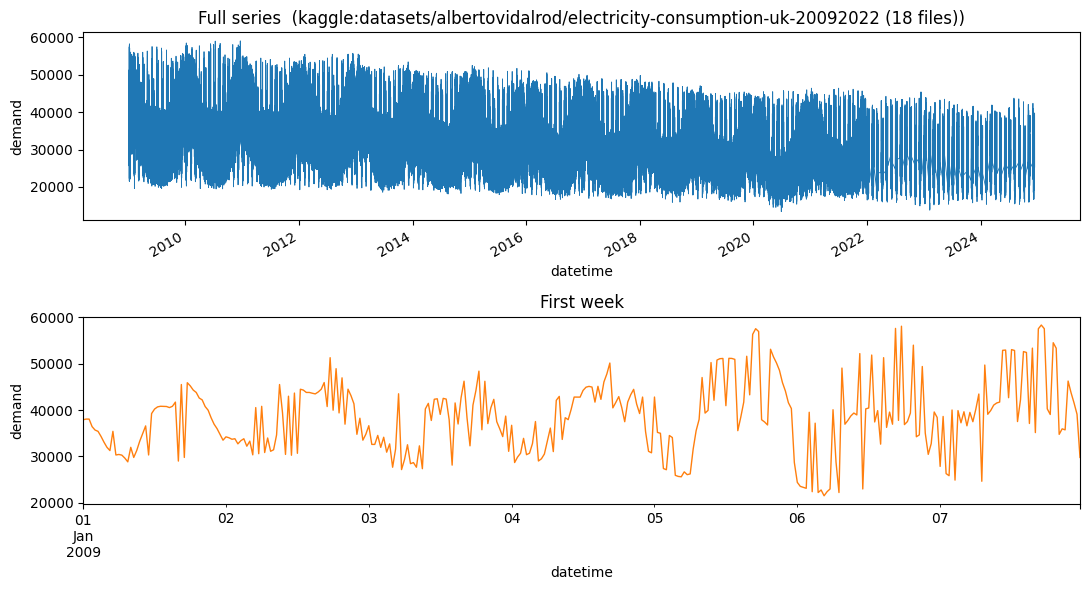

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
demand_df["demand"].plot(ax=axes[0], lw=0.6)
axes[0].set_title(f"Full series  ({source_tag})")
axes[0].set_ylabel("demand")
week = demand_df.iloc[: 48 * 7]
week["demand"].plot(ax=axes[1], lw=1.0, color="C1")
axes[1].set_title("First week")
axes[1].set_ylabel("demand")
plt.tight_layout()
plt.show()


## 6. Feature engineering

Calendar features (hour, day-of-week, month, day-of-year as sin/cos pairs), a weekend flag, lagged demand at 1, 2, 48 (one day) and 336 (one week) half-hour steps, and rolling means over the same windows.


In [6]:
LAGS = [1, 2, 48, 336]
ROLLS = [48, 336]


def build_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    out = pd.DataFrame(index=df.index)
    idx = df.index
    out["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
    out["dow_sin"] = np.sin(2 * np.pi * idx.dayofweek / 7)
    out["dow_cos"] = np.cos(2 * np.pi * idx.dayofweek / 7)
    out["month_sin"] = np.sin(2 * np.pi * (idx.month - 1) / 12)
    out["month_cos"] = np.cos(2 * np.pi * (idx.month - 1) / 12)
    out["doy_sin"] = np.sin(2 * np.pi * (idx.dayofyear - 1) / 365)
    out["doy_cos"] = np.cos(2 * np.pi * (idx.dayofyear - 1) / 365)
    out["is_weekend"] = (idx.dayofweek >= 5).astype(float)
    for L in LAGS:
        out[f"lag_{L}"] = df["demand"].shift(L)
    for W in ROLLS:
        out[f"roll_{W}"] = df["demand"].shift(1).rolling(W, min_periods=W).mean()
    out["y"] = df["demand"].values
    out = out.dropna()
    y = out.pop("y")
    return out, y


X_df, y_ser = build_features(demand_df)
print(f"Feature matrix: {X_df.shape}, target: {y_ser.shape}")
X_df.head()


Feature matrix: (248806, 15), target: (248806,)


,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,is_weekend,lag_1,lag_2,lag_48,lag_336,roll_48,roll_336
datetime,,,,,,,,,,,,,,,
2009-01-08 00:00:00,0.000000,1.000000,0.433884,-0.900969,0.0,1.0,0.120208,0.992749,0.0,29790.0,39085.0,27857.0,37910.0,41807.187500,38386.729167
2009-01-08 00:30:00,0.000000,1.000000,0.433884,-0.900969,0.0,1.0,0.120208,0.992749,0.0,24833.0,29790.0,38615.0,38047.0,41744.187500,38347.809524
2009-01-08 01:00:00,0.258819,0.965926,0.433884,-0.900969,0.0,1.0,0.120208,0.992749,0.0,23818.0,24833.0,26313.0,38047.0,41435.916667,38305.461310
2009-01-08 01:30:00,0.258819,0.965926,0.433884,-0.900969,0.0,1.0,0.120208,0.992749,0.0,23360.0,23818.0,25857.0,36426.0,41374.395833,38261.750000
2009-01-08 02:00:00,0.500000,0.866025,0.433884,-0.900969,0.0,1.0,0.120208,0.992749,0.0,37165.0,23360.0,39998.0,35687.0,41609.979167,38263.949405


## 7. Time-based split + standardisation


In [7]:
from sklearn.preprocessing import StandardScaler

n = len(X_df)
i_train_end = int(n * 0.70)
i_val_end = int(n * 0.85)

X_train_raw = X_df.iloc[:i_train_end].values
X_val_raw = X_df.iloc[i_train_end:i_val_end].values
X_test_raw = X_df.iloc[i_val_end:].values
y_train_raw = y_ser.iloc[:i_train_end].values.astype(np.float32)
y_val_raw = y_ser.iloc[i_train_end:i_val_end].values.astype(np.float32)
y_test_raw = y_ser.iloc[i_val_end:].values.astype(np.float32)
test_index = y_ser.iloc[i_val_end:].index

x_scaler = StandardScaler().fit(X_train_raw)
X_train = x_scaler.transform(X_train_raw).astype(np.float32)
X_val = x_scaler.transform(X_val_raw).astype(np.float32)
X_test = x_scaler.transform(X_test_raw).astype(np.float32)

y_mean = float(y_train_raw.mean())
y_std = float(y_train_raw.std() + 1e-8)
y_train = ((y_train_raw - y_mean) / y_std).astype(np.float32)
y_val = ((y_val_raw - y_mean) / y_std).astype(np.float32)
y_test = ((y_test_raw - y_mean) / y_std).astype(np.float32)

print(f"train / val / test : {len(y_train)}, {len(y_val)}, {len(y_test)}")
print(f"y mean / std (train, raw) : {y_mean:.4f} / {y_std:.4f}")


train / val / test : 174164, 37321, 37321
y mean / std (train, raw) : 33542.4609 / 7719.9082


## 8. Sinh-arcsinh MLP + NLL

The output head produces $(\mu,\ \log\sigma,\ \varepsilon,\ \log\delta)$. Letting $s = (y - \mu)/\sigma$ and $z = \sinh(\delta\,\operatorname{arcsinh} s - \varepsilon)$:

$$\log p(y \mid \mu,\sigma,\varepsilon,\delta) = \log\delta - \log\sigma - \tfrac12\log 2\pi + \log\cosh(\delta\,\operatorname{arcsinh} s - \varepsilon) - \tfrac12\log(1 + s^2) - \tfrac12 z^2.$$

`log cosh` is implemented in the numerically stable form $|u| + \operatorname{softplus}(-2|u|) - \log 2$.


In [8]:
import torch.nn as nn
import torch.nn.functional as F


class SinhArcsinhMLP(nn.Module):
    def __init__(self, in_dim: int, hidden: tuple[int, int] = (256, 128), dropout: float = 0.1):
        super().__init__()
        h1, h2 = hidden
        self.body = nn.Sequential(
            nn.Linear(in_dim, h1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h1, h2), nn.ReLU(), nn.Dropout(dropout),
        )
        self.head = nn.Linear(h2, 4)

    def forward(self, x: torch.Tensor):
        h = self.body(x)
        raw = self.head(h)
        mu = raw[:, 0]
        sigma = F.softplus(raw[:, 1]) + 1e-3
        eps = raw[:, 2]
        delta = F.softplus(raw[:, 3]) + 1e-3
        return mu, sigma, eps, delta


_HALF_LOG_2PI = 0.5 * math.log(2 * math.pi)


def sas_nll(y, mu, sigma, eps, delta):
    s = (y - mu) / sigma
    a = torch.asinh(s)
    u = delta * a - eps
    z = torch.sinh(u)
    log_cosh_u = u.abs() + F.softplus(-2.0 * u.abs()) - math.log(2.0)
    log_p = (
        torch.log(delta) - torch.log(sigma) - _HALF_LOG_2PI
        + log_cosh_u
        - 0.5 * torch.log1p(s * s)
        - 0.5 * z * z
    )
    return -log_p.mean()


## 9. Training loop

AdamW, early stopping on val NLL with patience 5. On TPU we call `xm.mark_step()` once per batch.


In [9]:
from torch import optim
from torch.utils.data import DataLoader, TensorDataset

BATCH = 1024
EPOCHS = 30
PATIENCE = 5
LR = 1e-3


def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool) -> DataLoader:
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle, drop_last=False)


train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val, shuffle=False)

model = SinhArcsinhMLP(in_dim=X_train.shape[1]).to(device)
opt = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)

best_val = float("inf")
best_state: dict | None = None
bad_epochs = 0
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(set_to_none=True)
        mu, sigma, eps, delta = model(xb)
        loss = sas_nll(yb, mu, sigma, eps, delta)
        loss.backward()
        opt.step()
        if BACKEND == "xla":
            xm.mark_step()
        train_losses.append(float(loss.detach().cpu()))

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            mu, sigma, eps, delta = model(xb)
            val_losses.append(float(sas_nll(yb, mu, sigma, eps, delta).detach().cpu()))
            if BACKEND == "xla":
                xm.mark_step()

    tr = float(np.mean(train_losses))
    vl = float(np.mean(val_losses))
    print(f"epoch {epoch:02d}  train NLL {tr:+.4f}  val NLL {vl:+.4f}  ({time.time()-t0:5.1f}s)")
    if vl + 1e-5 < best_val:
        best_val = vl
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"early-stop @ epoch {epoch} (best val NLL = {best_val:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)
model.eval()
print(f"done. best val NLL = {best_val:.4f}")


epoch 01  train NLL +0.4189  val NLL -0.0250  (  2.6s)
epoch 02  train NLL +0.1042  val NLL -0.2021  (  4.4s)
epoch 03  train NLL +0.0112  val NLL -0.1367  (  6.3s)
epoch 04  train NLL -0.0489  val NLL -0.2243  (  8.1s)
epoch 05  train NLL -0.1010  val NLL -0.3564  ( 10.0s)
epoch 06  train NLL -0.1420  val NLL -0.3581  ( 11.8s)
epoch 07  train NLL -0.1748  val NLL -0.3275  ( 13.6s)
epoch 08  train NLL -0.2012  val NLL -0.4863  ( 15.5s)
epoch 09  train NLL -0.2224  val NLL -0.4896  ( 17.3s)
epoch 10  train NLL -0.2386  val NLL -0.5044  ( 19.3s)
epoch 11  train NLL -0.2609  val NLL -0.5151  ( 21.1s)
epoch 12  train NLL -0.2741  val NLL -0.4706  ( 22.9s)
epoch 13  train NLL -0.2882  val NLL -0.4631  ( 24.8s)
epoch 14  train NLL -0.2972  val NLL -0.5789  ( 26.6s)
epoch 15  train NLL -0.3079  val NLL -0.5151  ( 28.4s)
epoch 16  train NLL -0.3141  val NLL -0.4541  ( 30.2s)
epoch 17  train NLL -0.3256  val NLL -0.4056  ( 32.0s)
epoch 18  train NLL -0.3271  val NLL -0.5322  ( 33.9s)
epoch 19  

## 10. Predict, quantiles, samples

For sinh-arcsinh, the quantile function is closed-form: $q_\alpha = \mu + \sigma \sinh\!\big((\Phi^{-1}(\alpha) + \varepsilon) / \delta\big)$.

For CRPS we use the sample-based estimator $\widehat{\text{CRPS}} = \mathbb{E}|Y - y| - \tfrac12\,\mathbb{E}|Y - Y'|$ with 200 i.i.d. draws per test point.


In [10]:
from scipy.stats import norm

QUANTILES = np.array([0.025, 0.10, 0.25, 0.50, 0.75, 0.90, 0.975])


@torch.no_grad()
def predict_params(X: np.ndarray):
    mus, sigmas, epses, deltas = [], [], [], []
    loader = make_loader(X, np.zeros(len(X), dtype=np.float32), shuffle=False)
    for xb, _ in loader:
        xb = xb.to(device)
        mu, sigma, eps, delta = model(xb)
        if BACKEND == "xla":
            xm.mark_step()
        mus.append(mu.cpu().numpy())
        sigmas.append(sigma.cpu().numpy())
        epses.append(eps.cpu().numpy())
        deltas.append(delta.cpu().numpy())
    return (
        np.concatenate(mus),
        np.concatenate(sigmas),
        np.concatenate(epses),
        np.concatenate(deltas),
    )


mu_t, sigma_t, eps_t, delta_t = predict_params(X_test)

z_q = norm.ppf(QUANTILES)[None, :]
q_std = mu_t[:, None] + sigma_t[:, None] * np.sinh((np.arcsinh(z_q) + eps_t[:, None]) / delta_t[:, None])
quantiles_pred = q_std * y_std + y_mean

N_SAMPLES = 200
rng = np.random.default_rng(SEED)
z_samp = rng.standard_normal((N_SAMPLES, len(mu_t)))
y_samples_std = mu_t[None, :] + sigma_t[None, :] * np.sinh((np.arcsinh(z_samp) + eps_t[None, :]) / delta_t[None, :])
y_samples = y_samples_std * y_std + y_mean

print(f"quantiles_pred : {quantiles_pred.shape}")
print(f"y_samples      : {y_samples.shape}")


quantiles_pred : (37321, 7)
y_samples      : (200, 37321)


## 11. Metrics


In [11]:
def pinball(y: np.ndarray, q_pred: np.ndarray, qs: np.ndarray) -> np.ndarray:
    e = y[:, None] - q_pred
    return np.maximum(qs * e, (qs - 1.0) * e).mean(axis=0)


def crps_sample(y: np.ndarray, samples: np.ndarray) -> float:
    # samples shape (S, N). Memory-light pairwise term: stream over sample pairs.
    S, N = samples.shape
    term1 = np.mean(np.abs(samples - y[None, :]))
    samples_sorted = np.sort(samples, axis=0)
    weights = (2 * np.arange(1, S + 1) - S - 1) / (S * S)
    term2 = float((weights[:, None] * samples_sorted).sum(axis=0).mean())
    return float(term1 - term2)


pb = pinball(y_test_raw, quantiles_pred, QUANTILES)
cov80 = float(((y_test_raw >= quantiles_pred[:, 1]) & (y_test_raw <= quantiles_pred[:, 5])).mean())
cov95 = float(((y_test_raw >= quantiles_pred[:, 0]) & (y_test_raw <= quantiles_pred[:, 6])).mean())
crps = crps_sample(y_test_raw, y_samples)

metrics_df = pd.DataFrame({"quantile": QUANTILES, "pinball": pb})
print(metrics_df.to_string(index=False))
print()
print(f"mean pinball : {pb.mean():.4f}")
print(f"CRPS         : {crps:.4f}")
print(f"PI 80%% cov   : {cov80:.3f}   (target 0.80)".replace("%%", "%"))
print(f"PI 95%% cov   : {cov95:.3f}   (target 0.95)".replace("%%", "%"))


 quantile    pinball
    0.025 164.755053
    0.100 447.261466
    0.250 761.151331
    0.500 930.865080
    0.750 802.937012
    0.900 530.694756
    0.975 219.888010

mean pinball : 551.0790
CRPS         : 1400.2676
PI 80% cov   : 0.840   (target 0.80)
PI 95% cov   : 0.955   (target 0.95)


## 12. Forecast plot


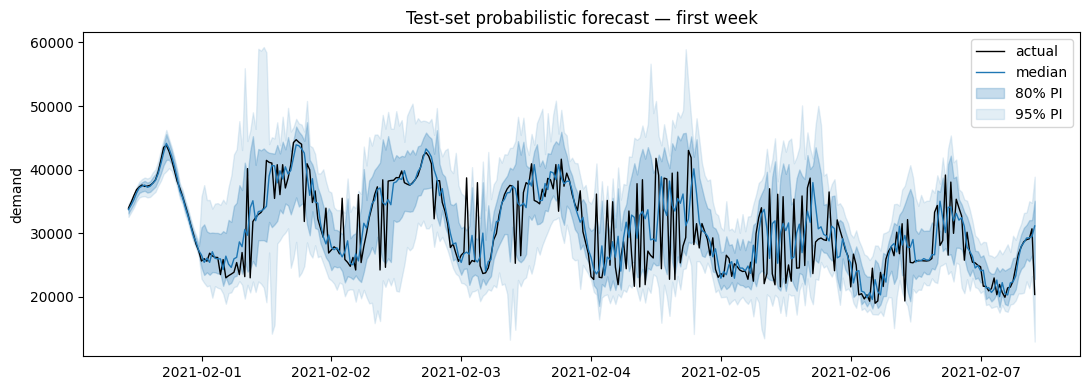

In [12]:
plot_n = min(48 * 7, len(test_index))
sl = slice(0, plot_n)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test_index[sl], y_test_raw[sl], color="black", lw=1.0, label="actual")
ax.plot(test_index[sl], quantiles_pred[sl, 3], color="C0", lw=1.0, label="median")
ax.fill_between(test_index[sl], quantiles_pred[sl, 1], quantiles_pred[sl, 5], color="C0", alpha=0.25, label="80% PI")
ax.fill_between(test_index[sl], quantiles_pred[sl, 0], quantiles_pred[sl, 6], color="C0", alpha=0.12, label="95% PI")
ax.legend(loc="upper right")
ax.set_title("Test-set probabilistic forecast — first week")
ax.set_ylabel("demand")
plt.tight_layout()
plt.show()


## 13. Summary

This notebook is the working stand-in for phases 1–5 of the `gpu_grid_forecast` package:

| Phase | Project location | Notebook section |
|-------|------------------|------------------|
| 1 — data ingestion | `src/gpu_grid_forecast/data/` | section 4 |
| 2 — feature builder | `src/gpu_grid_forecast/features/` | section 6 |
| 3 — evaluation harness | `src/gpu_grid_forecast/eval/` | section 11 |
| 5 — sinh-arcsinh MLP | `src/gpu_grid_forecast/models/` | sections 8–9 |

To run on Kaggle: attach a UK demand dataset, set `DATASET_NAME` to its slug, pick **GPU P100**, **GPU T4 x2**, or **TPU VM v5e-8**, and *Run all*.
